# Medical insurance Model

In [1]:
# imports
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [2]:
dataset = pd.read_csv("../notebooks/datasets/medical_insurance.csv")

dataset.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [3]:
dataset.describe().loc[["count", "mean", "min", "max"]]

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.0,100000.0000,100000.000,100000.0000,100000.00000,100000.000000,100000.00000,100000.00000,100000.00000,100000.00000,...,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.00000,100000.0000
mean,50000.5,47.5215,49873.905,2.4309,0.89838,26.990512,1.92765,0.09364,0.37335,1.23632,...,0.01477,0.10831,0.13014,0.50853,0.15869,0.50839,0.50933,0.50914,0.36781,0.1697
min,1.0,0.0000,1100.000,1.0000,0.00000,12.000000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000
max,100000.0,100.0000,1061800.000,9.0000,7.00000,50.400000,25.00000,3.00000,21.00000,11.00000,...,1.00000,1.00000,1.00000,7.00000,6.00000,7.00000,7.00000,7.00000,1.00000,1.0000


In [4]:
dataset.isna().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

En la siguiente celda se muestra que el conjunto de datos tiene la mayoría de sus columnas completas, es decir, sin datos nulos. 


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

## EDA

El conjunto cuenta con un total de 54 columnas, después de un análisis se escogieron 20 de las 54 columnas. Se busca minimizar la cantidad de columnas a responder por el usuario, manteniendo datos importantes. Las columnas que se escogieron son las siguientes:

- Age
- Sex
- Dependents
- Region 
- Smoker
- Bmi
- Visits_last_year
- Hospitalizations_last_3yrs
- Medication_count
- Plan_type
- Network_tier
- Chronic_count
- Hypertension
- Diabetes
- Deductible
- Copay
- cardiovascular_disease
- Arthritis
- Mental_health
- had _major_procedure

Para escoger las columnas se tomaron en cuenta categorías relacionadas a la salud médica del usuario, características en torno al tipo de seguro médico, y datos del usuario como región y beneficiarios dependientes.


Se detectaron irregularidades en el conjunto de datos, principalmente se mostraban usuarios de edad menor a 18 años. En Estados Unidos, los menores de 18 no pueden contar con seguro médico, por esto, se decidió eliminar las filas en las que los usuarios son menores de 18 años.

In [6]:
data = dataset[dataset["age"] >= 18]

### Data Visualization

#### Visualization of Numerical features

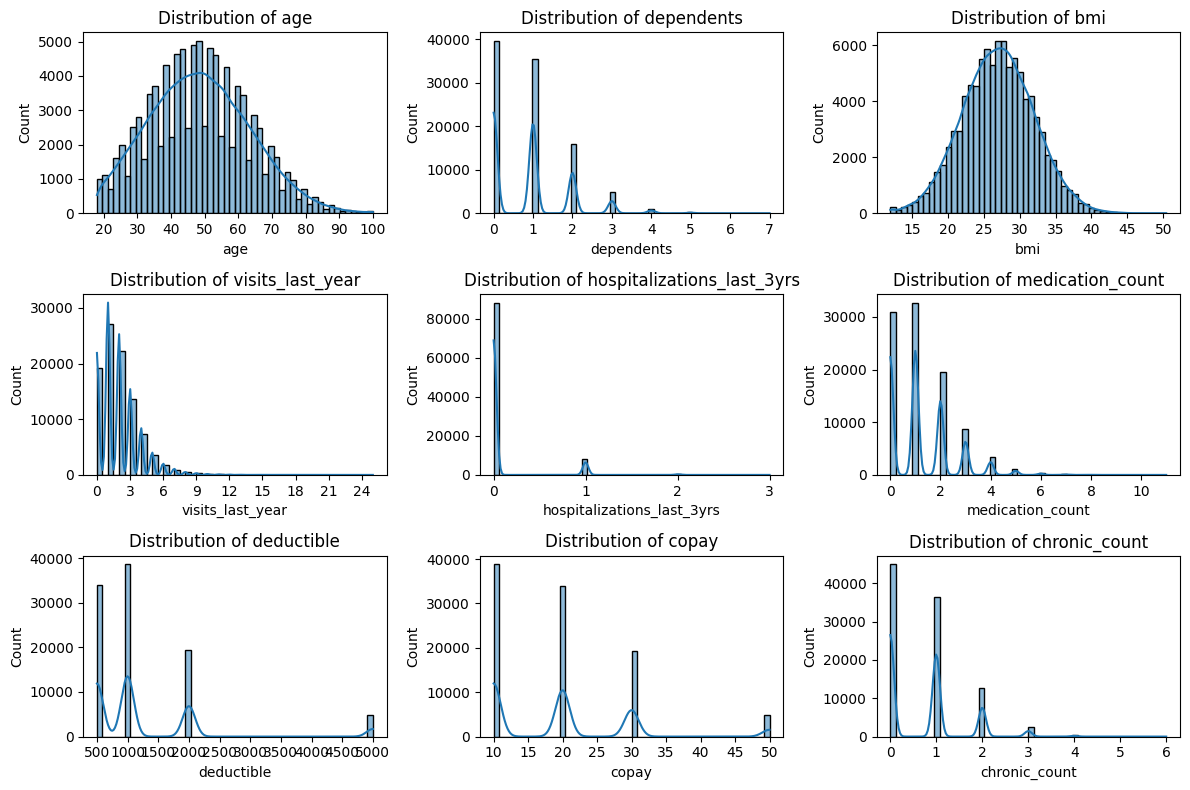

In [7]:
from matplotlib.ticker import MaxNLocator

numerical_cols = ["age", "dependents", "bmi", "visits_last_year", "hospitalizations_last_3yrs", "medication_count", "deductible", "copay", "chronic_count"]

fig, axs = plt.subplots(3, 3, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax, linewidth=1, bins=50)
    ax.set_title(f'Distribution of {col}')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()

#### Visualization of Categorical features

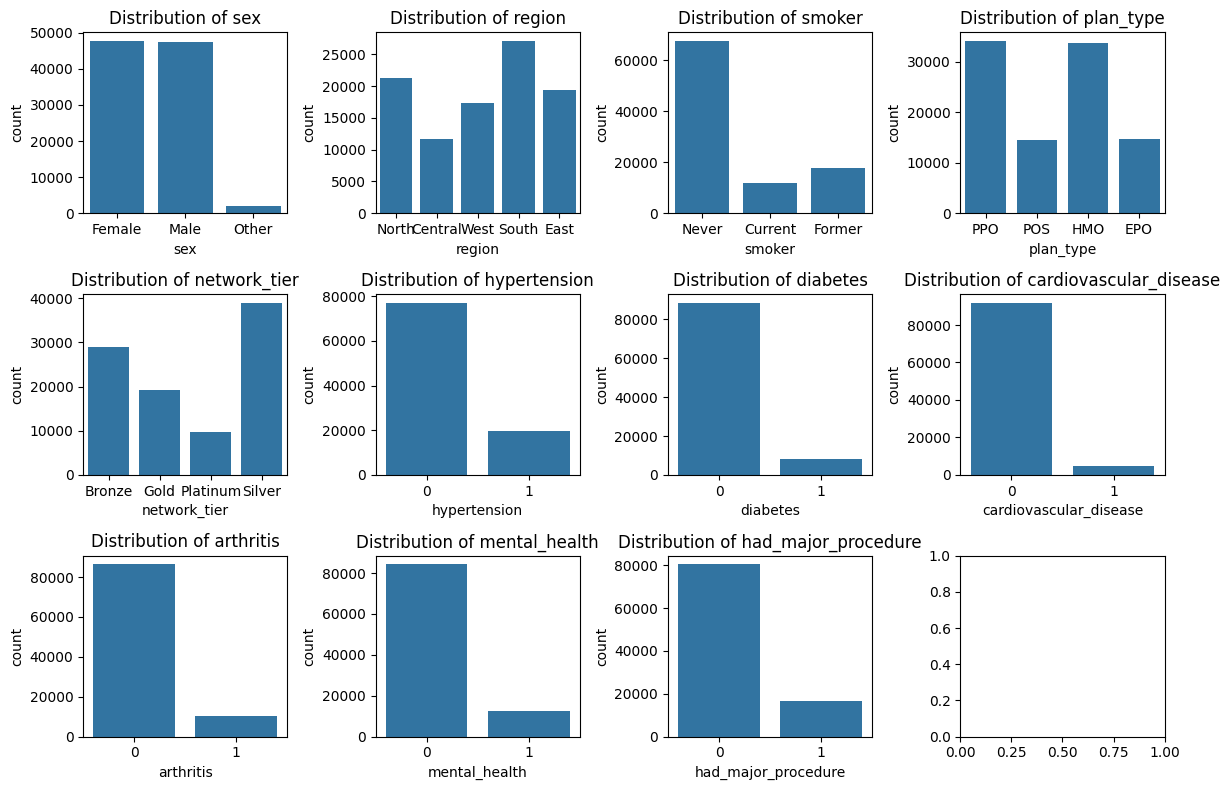

In [8]:
categorical_cols = ["sex", "region", "smoker", "plan_type", "network_tier", "hypertension", "diabetes", "cardiovascular_disease", "arthritis", "mental_health", "had_major_procedure"]

fig, axs = plt.subplots(3, 4, figsize=(12, 8))

for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(x=data[col], ax=ax)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

#### Target label distribution

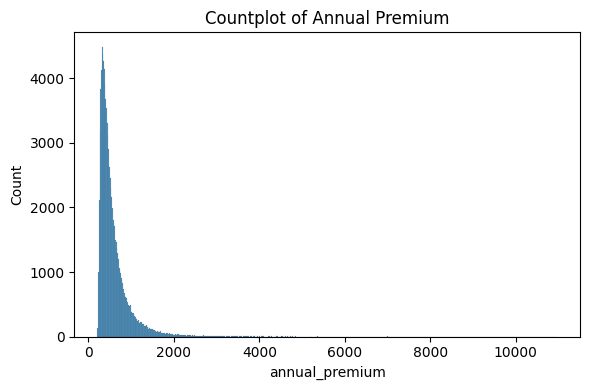

In [9]:
fig = plt.figure(figsize=(6, 4))
sns.histplot(data=data, x='annual_premium')
plt.title('Countplot of Annual Premium')
plt.tight_layout()

### Correlations

En la siguiente gráfica se analiza la correlación de las características en torno a la variable de salida. Se detectó que las características copay, dependents y deductible tienen una baja correlación con la variable de salida. Aún así se concluyó que los tres son parámetros necesarios e importantes para las aseguradoras, por lo que la decisión final fue mantenerlas en el modelo. Las demás características cuentan con suficiente relevancia y correlación para también ser parte del modelo.

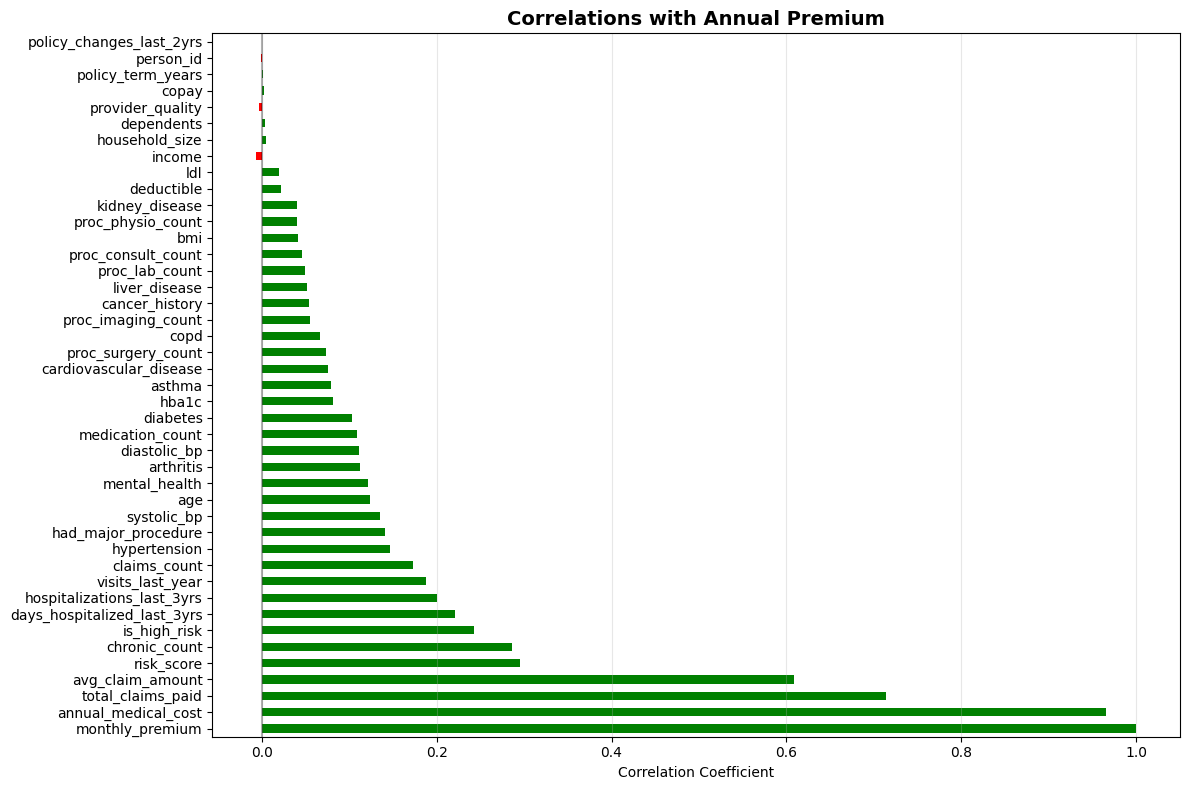

In [10]:
annual_premium_corr = data.corr(numeric_only=True)['annual_premium'].sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 8))
annual_premium_corr.drop('annual_premium').plot(kind='barh', 
                                                color=['red' if x < 0 else 'green' for x in annual_premium_corr.drop('annual_premium').values])
plt.title('Correlations with Annual Premium', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

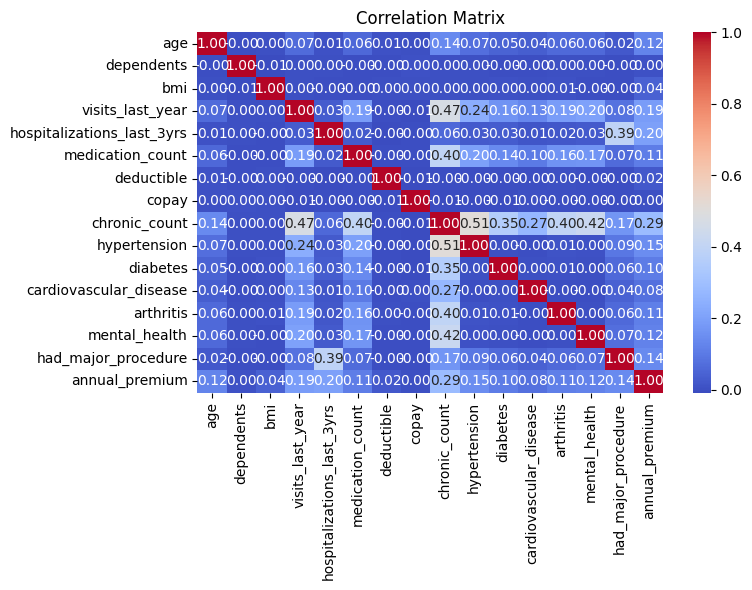

In [11]:
corr_matrix = data[numerical_cols + categorical_cols + ["annual_premium"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()


Anteriormente se identificó que el conjunto de datos tiene la mayoría de sus columnas completas, en este caso todas las características escogidas para el modelo tienen sus datos correspondientes. Debido a esto no es necesario aplicar técnicas de sustitución como SimpleImputer. A continuación se muestra evidencia de la cantidad de filas vacías por cada una de las columnas (0).


<Axes: >

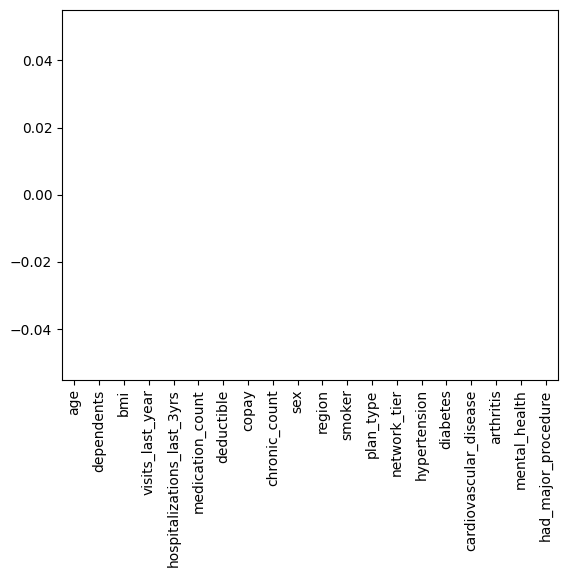

In [12]:
missing_counts = data[numerical_cols + categorical_cols].isnull().sum()
missing_counts.plot(kind='bar')

## Preprocessing

Se identificaron cuatro transformadores necesarios para el pipeline de preprocesamiento. A las características *sex*, *region* y *plan_type* se aplicó **One Hot Encoder** ya que sus categorías no son ordenadas. 

A las características *smoker* y *network_tier* se aplica **Ordinal Encoder** debido a su naturaleza ordinal. *Smoker* se divide en Siempre, Antes, Sí en referencia a los hábitos  del usuario, por lo que su peso es dependiente de la categoría, de la misma manera *network_tier* se divide en cuatro categorías, donde cada categoría es considerada mejor que la anterior.

A las categorías *age* y *bmi* se aplicó **Standard Scaler** para escalar los datos y balancear el peso con relación a otras categorías.

Finalmente, a las categorías *hospitalizations_last_3yrs*, *deductible*, *visits_last_year*, *copay*, *medication_count*, *dependents* y *chronic_count* se aplicó **Power Transformer** para contrarrestar su forma no normalizada y eliminar el sesgo, igual que el transformador anterior, se aplica **Standard Scaler** para escalar los datos.

Cabe recalcar que aunque no se identificaron filas vacías en el conjunto de datos, se decidió utilizar **Simple Imputer** para todos los transformadores. Se busca mitigar riesgos futuros por el uso del modelo. Es decir, si en un futuro es necesario probar datos más desordenados, tener **Simple Imputer** en el pipeline mantiene orden.

In [13]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('cat_OHE', make_pipeline(
                SimpleImputer(missing_values=" ",strategy='most_frequent'), ## IMPORTANTE DEJAR MISSING VALUES = " " , porque hay conflictos de formato entre onnx y el simple imputer
                OneHotEncoder(handle_unknown="ignore") 
            ), ["sex", "region", "plan_type"]),
            ('cat_Ordinal', make_pipeline(
                SimpleImputer(missing_values=" " ,strategy='most_frequent'),  
                OrdinalEncoder()
            ), ["smoker", "network_tier"]),
            ('skewed_numerical', make_pipeline(
                SimpleImputer(strategy='median'),
                PowerTransformer(),
                StandardScaler()
            ), ["hospitalizations_last_3yrs", "deductible", "visits_last_year", "copay", "medication_count", "dependents", "chronic_count"]),
            ('normal_numerical', make_pipeline(
                SimpleImputer(strategy='mean'), 
                StandardScaler()
            ), ["age", "bmi"]),
        ],
        remainder='passthrough'  
    )
)

Dividimos los datos en conjunto de prueba y conjunto de entrenamiento con porcentaje 80-20

In [14]:
x = data[numerical_cols + categorical_cols]
y = data["annual_premium"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

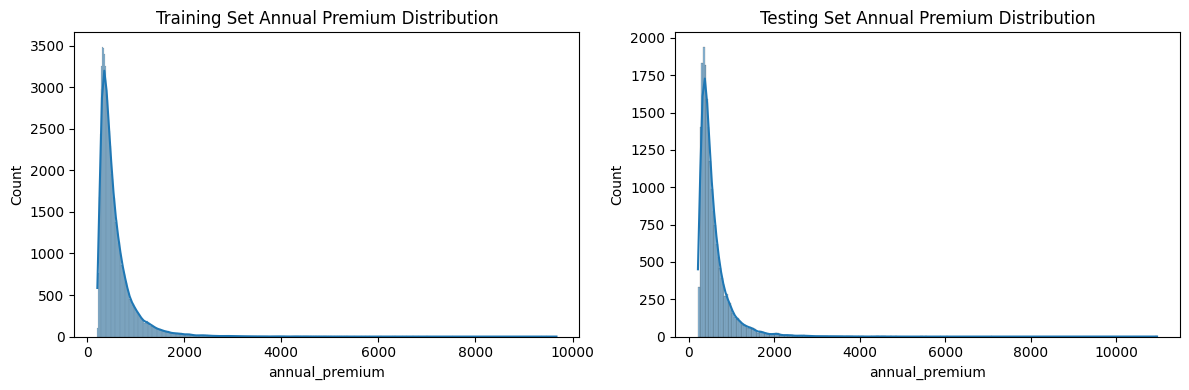

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, kde=True, ax=axs[0])
axs[0].set_title('Training Set Annual Premium Distribution')
sns.histplot(y_test, kde=True, ax=axs[1])
axs[1].set_title('Testing Set Annual Premium Distribution')
fig.tight_layout()

 Aplicamos fit transform a los datos de entrenamiento y transform a los datos de prueba.

In [16]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_train_processed

array([[1., 0., 0., ..., 1., 1., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 1.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 1.]], shape=(77564, 29))

In [17]:
x_test_processed = preprocessing_pipeline.transform(x_test)
x_test_processed

array([[0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(19392, 29))

In [18]:
import numpy as np

np.isnan(x_train_processed).sum()              # total NaNs
np.isnan(x_train_processed).sum(axis=0)    

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

# Modeling

Antes de empezar a modelar funciones de Machine Learning, vamos a visualizar cuantas columnas quedaron antes y despues del preprocesamiento, esto es util para poder serializar el modelo usando ONNX despues, y tambien para tener en cuenta los hiperparametros de nuestro modelo de ML

In [19]:
print("Filas, columnas (antes):", x_train.shape)
print("Num columnas (antes):", x_train.shape[1])
print("Nombres de columnas:", list(x_train.columns))

Filas, columnas (antes): (77564, 20)
Num columnas (antes): 20
Nombres de columnas: ['age', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'medication_count', 'deductible', 'copay', 'chronic_count', 'sex', 'region', 'smoker', 'plan_type', 'network_tier', 'hypertension', 'diabetes', 'cardiovascular_disease', 'arthritis', 'mental_health', 'had_major_procedure']


In [20]:
Xt = preprocessing_pipeline.fit_transform(x_train)
print("Filas, columnas (despues):", Xt.shape)
print("Num columnas (despues):", Xt.shape[1])

Filas, columnas (despues): (77564, 29)
Num columnas (despues): 29


Se puede mirar que antes de aplicar el pipeline de preprocesamiento tenemos 20 columnas y despues tenemos 29, esto se debe a que implementamos One Hot Encoder (OHE), que por cada clase de una columna categorica (de strings) crea una columna numerica

**Proponer modelos de Machine Learning**

Para nuestros modelos de Machine Learning, propondremos 3 modelos de regresion y usaremos GridSearchCV en cada entrenamiento

Primero vamos a definir nuestra funcion de Cross Validation que vamos a reutilizar en nuestro codigo despues, para el CV utilizamos 5 folds ya que es la practica standar y una seed 42 para mantener reproducibilidad

In [21]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Usamos cross validation con 5 folds porque es lo mas generico, no usar 3 
cv = KFold(n_splits=5, shuffle=True, random_state=42)  # el seed para todas las celdas sera 42

Ahora vamos a definir la funcion para evaluar todos nuestros modelos, se va a reutilizar y contiene todas las 4 metricas de error de problemas de regresion, es un reporte completo para cada modelo para no sesgarnos y tener un panorama completo.

In [22]:
import numpy as np
from sklearn.model_selection import cross_validate

# Definimos los scores
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Funcino para volver a correr el modelo para dar metricas generales a parte de la objetivo
# REGULARMENTE SE USA CON EL MEJOR ESTIMADOR DEL ENTRENAMIENTO CV

def cv_metrics(model, X, y, cv):
    res = cross_validate(
        model, X, y,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False
    )
    out = {
        "MAE": -res["test_MAE"].mean(),
        "MSE": -res["test_MSE"].mean(),
        "RMSE": -res["test_RMSE"].mean(),
        "R2": res["test_R2"].mean(),
        "stds para ver cuanto cambian entre folds"
        "\nMAE_std": res["test_MAE"].std(),
        "RMSE_std": res["test_RMSE"].std(),
        "R2_std": res["test_R2"].std(),
    }
    return out

Nuestro primer modelo de machine learning que vamos a probar sera Ridge, útil para problemas con muchas features y muy ligero

In [23]:
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", Ridge(random_state=42))
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

gs_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_ridge.fit(x_train, y_train)

print("Ridge best params:", gs_ridge.best_params_)
print("Ridge best CV MAE:", -gs_ridge.best_score_)

best_ridge = gs_ridge.best_estimator_

metrics_ridge = cv_metrics(best_ridge, x_train, y_train, cv)
print("\nRidge CV metrics (promedio):")
for k, v in metrics_ridge.items():
    print(f"{k}: {v}")

Ridge best params: {'model__alpha': 100}
Ridge best CV MAE: 226.84525939447394

Ridge CV metrics (promedio):
MAE: 226.84525939447394
MSE: 137480.78018570616
RMSE: 370.7256314247288
R2: 0.14755568365359623
stds para ver cuanto cambian entre folds
MAE_std: 1.51021206164872
RMSE_std: 6.5792393513443175
R2_std: 0.005800124489233244


Ahora propondremos KNN Regressor, mas pesado que Ridge pero igual vale la pena probar

In [24]:
from sklearn.neighbors import KNeighborsRegressor

pipe_knn = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", KNeighborsRegressor())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_knn.fit(x_train, y_train)

print("KNN best params:", gs_knn.best_params_)
print("KNN best CV MAE:", -gs_knn.best_score_)

best_knn = gs_knn.best_estimator_

metrics_knn = cv_metrics(best_knn, x_train, y_train, cv)
print("\nKNN CV metrics (promedio):")
for k, v in metrics_knn.items():
    print(f"{k}: {v}")

KNN best params: {'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'uniform'}
KNN best CV MAE: 222.14557071618952

KNN CV metrics (promedio):
MAE: 222.14557071618952
MSE: 141405.25451506907
RMSE: 375.982598239474
R2: 0.12321126445181643
stds para ver cuanto cambian entre folds
MAE_std: 2.166527791030344
RMSE_std: 6.506945225171861
R2_std: 0.0028430206099263164


Por último proponemos usar Huber Regressor, el cual es resistente a outliers y eso sera beneficial para nuestro problema porque nuestro dataset tiene outliers sin manejo.

In [25]:
from sklearn.linear_model import HuberRegressor

pipe_huber = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", HuberRegressor(max_iter=2000))
])

param_grid_huber = {
    "model__epsilon": [1.35, 1.5, 1.75],  # robustez
    "model__alpha": [0.0, 0.001, 0.01],   # regularizacion
}

gs_huber = GridSearchCV(
    estimator=pipe_huber,
    param_grid=param_grid_huber,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_huber.fit(x_train, y_train)

print("Huber best params:", gs_huber.best_params_)
print("Huber best CV MAE:", -gs_huber.best_score_)

best_huber = gs_huber.best_estimator_

metrics_huber = cv_metrics(best_huber, x_train, y_train, cv)
print("\nHUBER REGRESOR CV metrics (promedio):")
for k, v in metrics_huber.items():
    print(f"{k}: {v}")

Huber best params: {'model__alpha': 0.01, 'model__epsilon': 1.35}
Huber best CV MAE: 211.6384705576241

HUBER REGRESOR CV metrics (promedio):
MAE: 211.6384705576241
MSE: 146587.34333094672
RMSE: 382.80949805132997
R2: 0.09108480533814348
stds para ver cuanto cambian entre folds
MAE_std: 1.8747316764430655
RMSE_std: 6.650679110854921
R2_std: 0.002485776662613832


# Métricas


Vamos a priorizar la metrica: **MAE**, porque nos da el error en el valor de los dolares del target entonces es interpretable, y tambien nuestro modelo actualmente tiene muchos outliers por lo que elegimos esta metrica robusta a outliers

NOTA: Para nuestras metricas vamos a priorizar mas tratar de no dar valores por debajo del valor real, porque en nuestro contexto de problema de negocio, no nos conviene decirle a nuestro cliente que su aseguranza le va a salir en 5000 pesos y que llegue y en realidad sean 10 mil pesos, lo mejor es predecir mas arriba cuando se pueda pero no mas abajo del valor real, obviamente manteniendo las predicciones con precision dentro de lo que cabe

**Probar el mejor modelo en test set**, el cual fue HuberRegressor

In [26]:
# best_huber ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_huber.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("Huber TEST MAE:", mae_test)

Huber TEST MAE: 210.85547649582398


**Probaremos los otros modelos con sus mejores estimadores no importa que no sea el huber, solo para ver si alguno tiene un mejor desempeno**

In [27]:
# best_knn ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_knn.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("KNN TEST MAE:", mae_test)

KNN TEST MAE: 221.72956130657712


In [28]:
# best_ridge ya esta guardado por el .best_estimator_ , porque puse (refit=True)
y_pred_test = best_ridge.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)

print("Ridge TEST MAE:", mae_test)

Ridge TEST MAE: 226.49919148778346


**Huber es el mejor, entonces haremos un reporte de desempeno solo para huber de manera final con deteccion de Overfitting**

HUBER - Metricas de entrenamiento 
MAE : 211.5624
MSE : 146540.3956
RMSE: 382.8060
R2  : 0.0914

HUBER - Metricas de test 
MAE : 210.8555
MSE : 146139.4956
RMSE: 382.2820
R2  : 0.0950


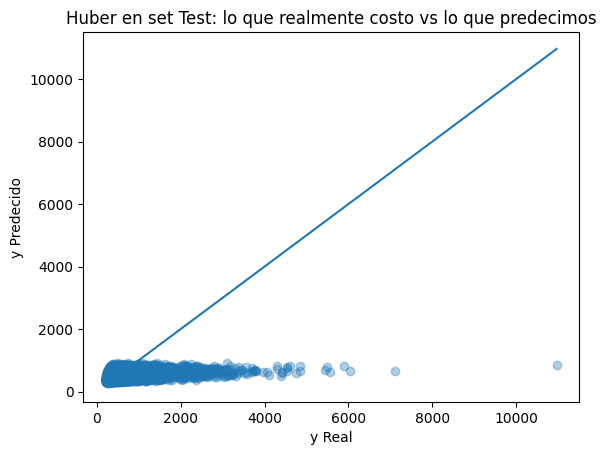

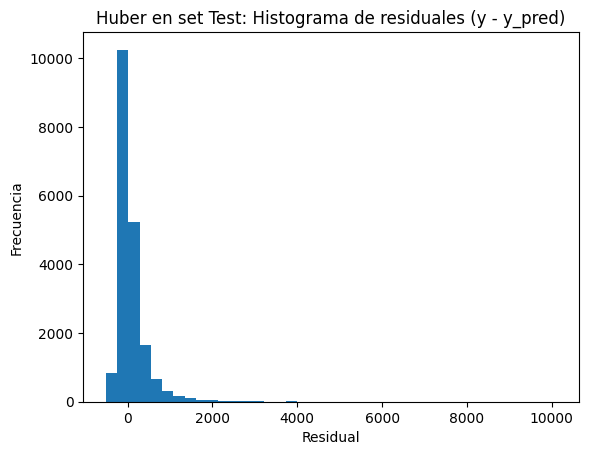

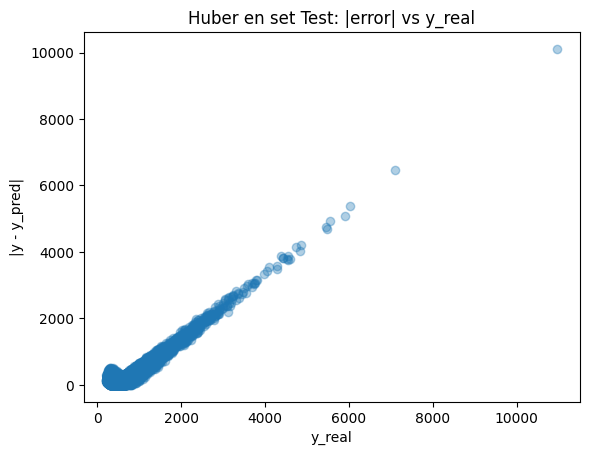

In [29]:
# Celda para evaluar huber, el mejor modelo

# Hacemos una inferencia sobre el set de entrenamiento y test, esto no reentrena el modelo ya que no usamos funcion fit
# Solo es inferencia no reentrenamiento

y_pred_train = best_huber.predict(x_train)
y_pred_test  = best_huber.predict(x_test)

# Definimos las metricas, mae, mse, rmse y r2 como las que hemos estado usando
def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Asignamos los valores de las metricas a variables
train_mae, train_mse, train_rmse, train_r2 = reg_metrics(y_train, y_pred_train)
test_mae,  test_mse,  test_rmse,  test_r2  = reg_metrics(y_test,  y_pred_test)

# Printeamos el reporte 
print("HUBER - Metricas de entrenamiento ")
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R2  : {train_r2:.4f}")

print("\nHUBER - Metricas de test ")
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R2  : {test_r2:.4f}")

# Este es el bloque para hacer las visualizaciones pertinentes 

# y_real vs y_pred
plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.35)
minv = min(np.min(y_test), np.min(y_pred_test))
maxv = max(np.max(y_test), np.max(y_pred_test))
plt.plot([minv, maxv], [minv, maxv])
plt.title("Huber en set Test: lo que realmente costo vs lo que predecimos")
plt.xlabel("y Real")
plt.ylabel("y Predecido")
plt.show()

# Histograma de residuales
res_test = y_test - y_pred_test
plt.figure()
plt.hist(res_test, bins=40)
plt.title("Huber en set Test: Histograma de residuales (y - y_pred)")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()

# error vs y_real
abs_err_test = np.abs(res_test)
plt.figure()
plt.scatter(y_test, abs_err_test, alpha=0.35)
plt.title("Huber en set Test: |error| vs y_real")
plt.xlabel("y_real")
plt.ylabel("|y - y_pred|")
plt.show()

Nos podemos dar cuenta que nuestro modelo no tiene overfitting porque nuestros resultados con el train set y el test set son muy similares, de hecho nuestro modelo se comportó mejor en nuestro test set.

A pesar de esto nuestro modelo no es buen predictor de acuerdo con nuestras métricas y las gráficas anteriormente descritas. Para esto regresaremos al preprocesamiento específicamente para lidiar con los outliers que estan causando mucho ruido en nuestros datos.

Modelo serializado exitosamente! , Listo para hacer inferencia.

### Remover OUTLIERS 

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split

# IQR bounds como nos enseno el profe 75 25
q1 = np.percentile(y_train, 25)
q3 = np.percentile(y_train, 75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

# quitamos train
keep_train = (y_train >= low) & (y_train <= high)
x_train_clean = x_train[keep_train]
y_train_clean = y_train[keep_train]

print("IQR low/high:", low, high)
print(f"Train removed: {(~keep_train).sum()} / {len(y_train)}")

# quitamos test pero usando lo que aprendio de train para evitar data leakage
keep_test = (y_test >= low) & (y_test <= high)
x_test_clean = x_test[keep_test]
y_test_clean = y_test[keep_test]

print(f"Test removed: {(~keep_test).sum()} / {len(y_test)}")



IQR low/high: -123.80999999999983 1148.1299999999997
Train removed: 5303 / 77564
Test removed: 1327 / 19392


## Reentrenar nuevo Huber sin outliers

Se busco reentrenar el modelo sin outliers ya que se identifico perdida de precision por la presencia de outliers. Este nuevo modelo reutiliza todo lo previo pero con un dataset optimizado y volvemos a ejecutar metricas y graficas para evaluar el nuevo modelo.

In [31]:
# REUZAMOS CODIGO pero con variables actualizadas


pipe_huber = Pipeline([
    ("prep", preprocessing_pipeline),
    ("model", HuberRegressor(max_iter=2000))
])

param_grid_huber = {
    "model__epsilon": [1.35, 1.5, 1.75],  # robustez
    "model__alpha": [0.0, 0.001, 0.01],   # regularizacion
}

gs_huber = GridSearchCV(
    estimator=pipe_huber,
    param_grid=param_grid_huber,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gs_huber.fit(x_train_clean, y_train_clean)

print("Huber best params:", gs_huber.best_params_)
print("Huber best CV MAE:", -gs_huber.best_score_)

best_huber_clean = gs_huber.best_estimator_

metrics_huber = cv_metrics(best_huber_clean, x_train_clean, y_train_clean, cv)
print("\nHUBER REGRESOR CV metrics (promedio):")
for k, v in metrics_huber.items():
    print(f"{k}: {v}")



Huber best params: {'model__alpha': 0.01, 'model__epsilon': 1.35}
Huber best CV MAE: 144.37535393537752

HUBER REGRESOR CV metrics (promedio):
MAE: 144.37535393537752
MSE: 36893.36995872474
RMSE: 192.07401907430372
R2: 0.11407593280030089
stds para ver cuanto cambian entre folds
MAE_std: 0.9559964662515725
RMSE_std: 0.9701316244469126
R2_std: 0.005752556694980382


### Evaluar en Test set Nuevo Huber sin outliers

HUBER - Metricas de entrenamiento (train_clean)
MAE : 144.3080
MSE : 36865.5544
RMSE: 192.0040
R2  : 0.1148

HUBER - Metricas de test (test_clean)
MAE : 143.0450
MSE : 36222.5598
RMSE: 190.3223
R2  : 0.1174


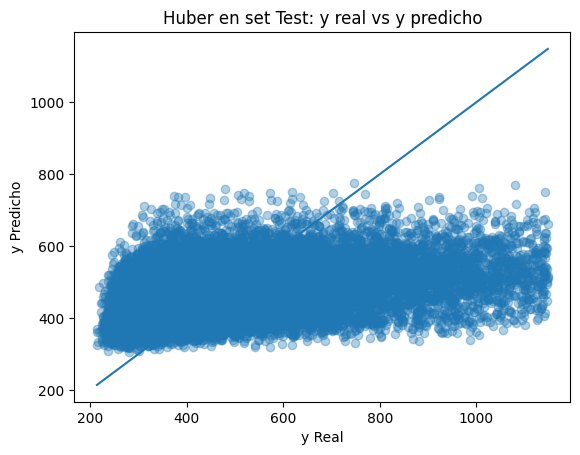

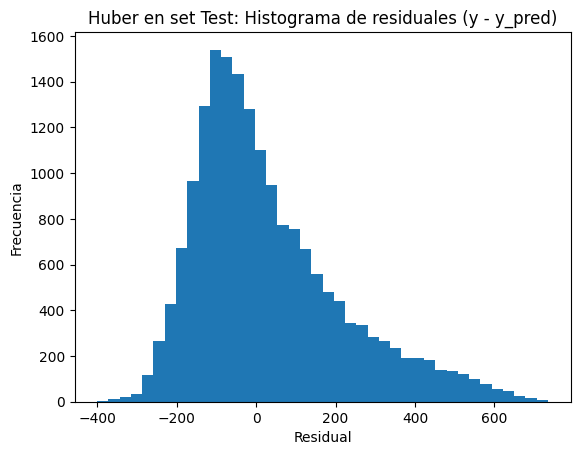

In [32]:
# EVALUAR HUBER


# Inferencia del modelo nuevo para datos de test y train
y_pred_train_huber = best_huber_clean.predict(x_train_clean)
y_pred_test_huber  = best_huber_clean.predict(x_test_clean)

# funcion para definir las metricas
def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


# Las metemos a variables las metricas de train y test
train_mae, train_mse, train_rmse, train_r2 = reg_metrics(y_train_clean, y_pred_train_huber)
test_mae,  test_mse,  test_rmse,  test_r2  = reg_metrics(y_test_clean,  y_pred_test_huber)

# Reporte
print("HUBER - Metricas de entrenamiento (train_clean)")
print(f"MAE : {train_mae:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R2  : {train_r2:.4f}")

print("\nHUBER - Metricas de test (test_clean)")
print(f"MAE : {test_mae:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R2  : {test_r2:.4f}")

# Visualizaciones


# y_real vs y_pred
plt.figure()
plt.scatter(y_test_clean, y_pred_test_huber, alpha=0.35)
minv = min(np.min(y_test_clean), np.min(y_pred_test_huber))
maxv = max(np.max(y_test_clean), np.max(y_pred_test_huber))
plt.plot([minv, maxv], [minv, maxv])
plt.title("Huber en set Test: y real vs y predicho")
plt.xlabel("y Real")
plt.ylabel("y Predicho")
plt.show()

# Histograma de residuales
res_test = y_test_clean - y_pred_test_huber
plt.figure()
plt.hist(res_test, bins=40)
plt.title("Huber en set Test: Histograma de residuales (y - y_pred)")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.show()


### Serializar el modelo nuevo sin outliers

Ahora proponemos el codigo para serializar el modelo, utilizaremos ONNX porque vamos a usar el modelo en un lenguaje de programacion diferente a python, entonces, para nuestro caso no nos funcionaria JobLib.

In [33]:
import os
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType, StringTensorType

# crear carpeta models
os.makedirs("models", exist_ok=True)

# Pasamos a pipe la variable best_huber que es el modelo con el mejor estimador ya entrenado en datos de entrenamiento listo para inferencia, e incluye
# el Preprocessing pipeline ahi mismo
pipe = best_huber_clean

# Definimos parametros del modelo
initial_types = [
    # numericas son float tensor
    ("age", FloatTensorType([None, 1])),
    ("dependents", FloatTensorType([None, 1])),
    ("bmi", FloatTensorType([None, 1])),
    ("visits_last_year", FloatTensorType([None, 1])),
    ("hospitalizations_last_3yrs", FloatTensorType([None, 1])),
    ("medication_count", FloatTensorType([None, 1])),
    ("deductible", FloatTensorType([None, 1])),
    ("copay", FloatTensorType([None, 1])),
    ("chronic_count", FloatTensorType([None, 1])),

    # las strings de verdad son string tensor
    ("sex", StringTensorType([None, 1])),
    ("region", StringTensorType([None, 1])),
    ("smoker", StringTensorType([None, 1])),
    ("plan_type", StringTensorType([None, 1])),
    ("network_tier", StringTensorType([None, 1])),
    
    # Las "categoricas" que son binarios entonces son float tensor
    ("hypertension", FloatTensorType([None, 1])),
    ("diabetes", FloatTensorType([None, 1])),
    ("cardiovascular_disease", FloatTensorType([None, 1])),
    ("arthritis", FloatTensorType([None, 1])),
    ("mental_health", FloatTensorType([None, 1])),
    ("had_major_procedure", FloatTensorType([None, 1])),
]

# En vez de usar to_onnx usamos sklearn porque es mas nuevo basicamente y mas robusto
onnx_model = convert_sklearn(pipe, initial_types=initial_types)

with open("models/huber_clean.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved models en carpeta/huber_clean.onnx")


Saved models en carpeta/huber_clean.onnx
